# SKILLNAV §N2.1 : Amélioration itérative du pipeline NER

> **Module** : M242 Analyse de Web · ENSA-Tétouan · Pr. Imad Sassi
> **Auteurs** : Karamo Sylla & Bachirou Konaté · **Soutenance** : 28 mai 2026
> **Prérequis** : avoir exécuté [`02_ner_comparison.ipynb`](./02_ner_comparison.ipynb)

---

## Objectif

Le baseline `DistilBERT-NER` retenu en §N2.1 obtient un F1 de **0.463**
sur le gold set de 30 fiches. Ce notebook applique quatre leviers
d'amélioration cumulatifs et mesure le gain F1 à chaque étape.

| Levier | Hypothèse à tester | Coût |
|---|---|---|
| **A. Post-processing** | Filtrer les entités de faible confiance (score < 0.5) et dédoublonner réduit les FP sans perdre de TP | Nul |
| **B. Matching enrichi** | Utiliser `SKILL_ALIASES` (190 variantes orthographiques) pour absorber `Pytorch` / `PyTorch`, `LLMs` / `LLM`, etc. | Nul |
| **C. Ensemble methods** | L'union des 3 BERT augmente le rappel, le vote majoritaire augmente la précision | Inférence déjà faite |
| **D. GLiNER zero-shot** | Modèle 2024 multilingue, accepte des labels custom adaptés au domaine RH (skill, framework, programming language) | ~5 minutes d'inférence |

Chaque amélioration est mesurée indépendamment, puis cumulée si elle
apporte un gain F1 significatif (> 0.02).


## 0. Setup


In [1]:
import json
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO / 'scripts'))
sys.path.insert(0, str(REPO / 'scripts' / 'ner'))

from skillnav_eda import SKILL_ALIASES, canonicaliser_skill  # noqa: E402

DATA_NER = REPO / 'data' / 'ner'

with open(DATA_NER / 'ner_gold_set.json', 'r', encoding='utf-8') as f:
    gold_set = json.load(f)
with open(DATA_NER / 'evaluation_n2_1.json', 'r', encoding='utf-8') as f:
    eval_baseline = json.load(f)

predictions = {}
for r in eval_baseline:
    model_key = r['modele']
    with open(DATA_NER / 'predictions' / f'{model_key}.json', 'r', encoding='utf-8') as f:
        predictions[model_key] = json.load(f)

print(f'Gold set     : {len(gold_set)} fiches')
print(f'Modèles      : {list(predictions.keys())}')
print(f'Skills total : {sum(len(g["gold_skills"]) for g in gold_set)}')

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
})


Gold set     : 30 fiches
Modèles      : ['bert_multilingual', 'camembert', 'distilbert']
Skills total : 543


### 0.1 Fonctions d'évaluation génériques


In [2]:
def texte_norm(s: str) -> str:
    return (s or '').strip().lower().strip(".,;:()[]{}\"'\u0060")


def skill_dans_entites(skill: str, entites: list, aliases: dict | None = None) -> bool:
    """Match souple. Si aliases fourni, on accepte aussi les variantes
    qui canonicalisent vers le même skill."""
    skill_norm = texte_norm(skill)
    if not skill_norm:
        return False
    skill_canon = (canonicaliser_skill(skill) or '').lower() if aliases else skill_norm
    for e in entites:
        e_norm = texte_norm(e.get('text', ''))
        if not e_norm:
            continue
        if skill_norm in e_norm or e_norm in skill_norm:
            return True
        if aliases:
            e_canon = (canonicaliser_skill(e.get('text', '')) or '').lower()
            if e_canon and (e_canon == skill_canon or skill_canon in e_canon or e_canon in skill_canon):
                return True
        ms = {m for m in skill_norm.split() if len(m) > 2}
        me = {m for m in e_norm.split() if len(m) > 2}
        if ms and me and (ms & me):
            return True
    return False


def entite_correspond_gold(entite: dict, gold_skills: list, aliases: dict | None = None) -> bool:
    for skill in gold_skills:
        if skill_dans_entites(skill, [entite], aliases=aliases):
            return True
    return False


def evaluer_pipeline(predictions_par_fiche: dict, gold_set: list, aliases: dict | None = None) -> dict:
    """Calcule P/R/F1 sur le gold set pour une pipeline donnée.

    predictions_par_fiche : dict {job_id: [entites]}
    """
    tp = fp = fn = total_pred = total_gold = 0
    for fiche in gold_set:
        gold_skills = fiche.get('gold_skills', [])
        total_gold += len(gold_skills)
        entites = predictions_par_fiche.get(fiche['job_id'], [])
        total_pred += len(entites)
        n_det = sum(1 for s in gold_skills if skill_dans_entites(s, entites, aliases=aliases))
        fn += len(gold_skills) - n_det
        tp += n_det
        for ent in entites:
            if not entite_correspond_gold(ent, gold_skills, aliases=aliases):
                fp += 1
    precision = tp / max(tp + fp, 1)
    rappel = tp / max(tp + fn, 1)
    f1 = (2 * precision * rappel / max(precision + rappel, 1e-9)) if (precision + rappel) else 0.0
    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': round(precision, 4),
        'rappel': round(rappel, 4),
        'f1': round(f1, 4),
        'n_entites_predites': total_pred,
        'n_skills_gold': total_gold,
    }


def predictions_dict(model_key: str) -> dict:
    return {p['job_id']: p['entites'] for p in predictions[model_key]['predictions']}


# Baseline DistilBERT (référence)
preds_distilbert = predictions_dict('distilbert')
baseline = evaluer_pipeline(preds_distilbert, gold_set)
print('=== Baseline DistilBERT ===')
print(f"  Précision : {baseline['precision']}  /  Rappel : {baseline['rappel']}  /  F1 : {baseline['f1']}")
print(f"  TP={baseline['tp']}  FP={baseline['fp']}  FN={baseline['fn']}")


=== Baseline DistilBERT ===
  Précision : 0.4428  /  Rappel : 0.4843  /  F1 : 0.4626
  TP=263  FP=331  FN=280


---

## A. Post-processing : filtrage par score + dédoublonnage

**Hypothèse :** les entités de faible confiance (score < seuil) sont
majoritairement des faux positifs. Filtrer + dédoublonner par texte
normalisé devrait améliorer la précision sans dégrader le rappel.


In [3]:
def post_process(entites: list, seuil_score: float = 0.5) -> list:
    """Filtre les entités par score, puis dédoublonne par texte normalisé."""
    filtre = [e for e in entites if e.get('score', 0.0) >= seuil_score]
    vu: set = set()
    out = []
    for e in filtre:
        cle = texte_norm(e.get('text', ''))
        if not cle or cle in vu:
            continue
        vu.add(cle)
        out.append(e)
    return out


# Test sur plusieurs seuils
resultats_seuils = []
for seuil in [0.0, 0.3, 0.5, 0.7, 0.85, 0.95]:
    preds_filt = {jid: post_process(ents, seuil_score=seuil) for jid, ents in preds_distilbert.items()}
    r = evaluer_pipeline(preds_filt, gold_set)
    r['seuil'] = seuil
    resultats_seuils.append(r)

df_seuils = pd.DataFrame(resultats_seuils)[['seuil', 'precision', 'rappel', 'f1', 'tp', 'fp', 'fn']]
print('=== Effet du seuil de score sur DistilBERT ===')
print(df_seuils.to_string(index=False))

seuil_optimal = max(resultats_seuils, key=lambda r: r['f1'])['seuil']
print(f"\nSeuil optimal : {seuil_optimal} (F1 = {max(resultats_seuils, key=lambda r: r['f1'])['f1']})")


=== Effet du seuil de score sur DistilBERT ===
 seuil  precision  rappel     f1  tp  fp  fn
  0.00     0.4962  0.4843 0.4902 263 267 280
  0.30     0.4962  0.4843 0.4902 263 267 280
  0.50     0.5071  0.4622 0.4836 251 244 292
  0.70     0.5477  0.4015 0.4633 218 180 325
  0.85     0.5167  0.2560 0.3424 139 130 404
  0.95     0.5000  0.1547 0.2363  84  84 459

Seuil optimal : 0.0 (F1 = 0.4902)


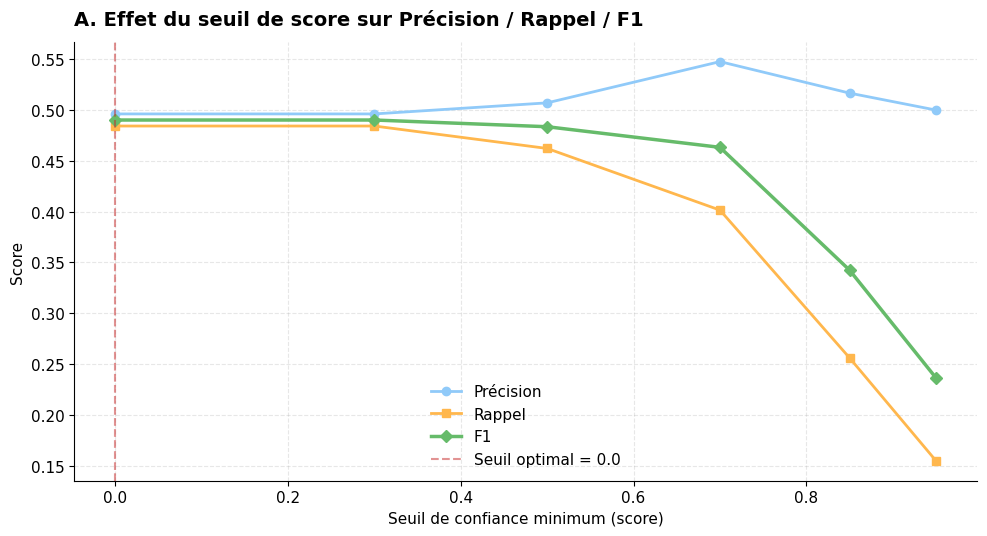


Gain F1 après levier A : +0.0276  (baseline 0.4626 -> 0.4902)


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(df_seuils['seuil'], df_seuils['precision'], marker='o', label='Précision', color='#90CAF9', linewidth=2)
ax.plot(df_seuils['seuil'], df_seuils['rappel'], marker='s', label='Rappel', color='#FFB74D', linewidth=2)
ax.plot(df_seuils['seuil'], df_seuils['f1'], marker='D', label='F1', color='#66BB6A', linewidth=2.5)
ax.axvline(seuil_optimal, color='#C62828', linestyle='--', alpha=0.5, label=f'Seuil optimal = {seuil_optimal}')
ax.set_xlabel('Seuil de confiance minimum (score)')
ax.set_ylabel('Score')
ax.legend(loc='best', frameon=False)
ax.set_title('A. Effet du seuil de score sur Précision / Rappel / F1', loc='left', pad=12)
plt.tight_layout()
FIGURES_DIR = REPO / 'docs' / 'figures'
fig.savefig(FIGURES_DIR / 'n21_amelioration_A_seuil.png', dpi=150, bbox_inches='tight')
plt.show()

preds_apres_A = {jid: post_process(ents, seuil_score=seuil_optimal) for jid, ents in preds_distilbert.items()}
resultat_A = evaluer_pipeline(preds_apres_A, gold_set)
gain_A = resultat_A['f1'] - baseline['f1']
print(f"\nGain F1 après levier A : {gain_A:+.4f}  (baseline {baseline['f1']} -> {resultat_A['f1']})")


---

## B. Matching gold enrichi par `SKILL_ALIASES`

**Hypothèse :** le dictionnaire `SKILL_ALIASES` (190 variantes) absorbe
`Pytorch`/`PyTorch`, `LLMs`/`LLM`, `Machine learning`/`Machine Learning`.
En l'utilisant dans la comparaison gold ↔ prédiction, on récupère des
matches que le matching strict laissait passer.


In [5]:
resultat_B = evaluer_pipeline(preds_apres_A, gold_set, aliases=SKILL_ALIASES)
gain_B = resultat_B['f1'] - resultat_A['f1']
print(f"=== Après B (post-proc + matching enrichi par alias) ===")
print(f"  Précision : {resultat_B['precision']}  /  Rappel : {resultat_B['rappel']}  /  F1 : {resultat_B['f1']}")
print(f"  Gain depuis A : {gain_B:+.4f}")
print(f"  Gain depuis baseline : {resultat_B['f1'] - baseline['f1']:+.4f}")


=== Après B (post-proc + matching enrichi par alias) ===
  Précision : 0.4981  /  Rappel : 0.4843  /  F1 : 0.4911
  Gain depuis A : +0.0009
  Gain depuis baseline : +0.0285


---

## C. Ensemble methods : combiner les 3 modèles BERT

**Hypothèse :** chacun des 3 modèles voit des entités différentes. Leur
combinaison devrait soit augmenter le rappel (union) soit augmenter la
précision (vote majoritaire). On teste les deux stratégies.


In [6]:
preds_bert = predictions_dict('bert_multilingual')
preds_camembert = predictions_dict('camembert')

# Post-processing identique pour tous (cohérence)
preds_bert_pp = {jid: post_process(ents, seuil_score=seuil_optimal) for jid, ents in preds_bert.items()}
preds_camembert_pp = {jid: post_process(ents, seuil_score=seuil_optimal) for jid, ents in preds_camembert.items()}
preds_distilbert_pp = preds_apres_A

# Stratégie 1 : UNION (toutes les entités détectées par >= 1 modèle, dédoublonnées)
def union_predictions(*sources: dict) -> dict:
    out: dict = {}
    for fiche in gold_set:
        jid = fiche['job_id']
        toutes_entites = []
        vu: set = set()
        for src in sources:
            for e in src.get(jid, []):
                cle = texte_norm(e.get('text', ''))
                if cle and cle not in vu:
                    vu.add(cle)
                    toutes_entites.append(e)
        out[jid] = toutes_entites
    return out


# Stratégie 2 : VOTE MAJORITAIRE (entités détectées par >= 2 modèles)
def vote_majoritaire(*sources: dict, min_votes: int = 2) -> dict:
    out: dict = {}
    for fiche in gold_set:
        jid = fiche['job_id']
        votes: dict = {}
        for src in sources:
            for e in src.get(jid, []):
                cle = texte_norm(e.get('text', ''))
                if not cle:
                    continue
                if cle not in votes:
                    votes[cle] = {'count': 0, 'entite': e}
                votes[cle]['count'] += 1
        out[jid] = [v['entite'] for v in votes.values() if v['count'] >= min_votes]
    return out


preds_union = union_predictions(preds_distilbert_pp, preds_bert_pp, preds_camembert_pp)
preds_vote = vote_majoritaire(preds_distilbert_pp, preds_bert_pp, preds_camembert_pp, min_votes=2)

resultat_C_union = evaluer_pipeline(preds_union, gold_set, aliases=SKILL_ALIASES)
resultat_C_vote = evaluer_pipeline(preds_vote, gold_set, aliases=SKILL_ALIASES)

print('=== C. Ensemble methods (avec post-proc + matching enrichi) ===\n')
print(f"  C1. Union 3 modèles    : P={resultat_C_union['precision']}  R={resultat_C_union['rappel']}  F1={resultat_C_union['f1']}")
print(f"  C2. Vote majoritaire   : P={resultat_C_vote['precision']}  R={resultat_C_vote['rappel']}  F1={resultat_C_vote['f1']}")
print(f"\n  Référence B (DistilBERT seul) : F1 = {resultat_B['f1']}")

best_C = max([
    ('Union', resultat_C_union),
    ('Vote majoritaire', resultat_C_vote),
    ('DistilBERT seul', resultat_B),
], key=lambda kv: kv[1]['f1'])
print(f"\nMeilleure variante : {best_C[0]} (F1 = {best_C[1]['f1']})")


=== C. Ensemble methods (avec post-proc + matching enrichi) ===

  C1. Union 3 modèles    : P=0.4449  R=0.5727  F1=0.5008
  C2. Vote majoritaire   : P=0.5119  R=0.0792  F1=0.1372

  Référence B (DistilBERT seul) : F1 = 0.4911

Meilleure variante : Union (F1 = 0.5008)


---

## D. GLiNER zero-shot avec labels custom du domaine

**Hypothèse :** GLiNER (Universal NER, NAACL 2024) accepte des labels
personnalisés sans fine-tuning. On lui demande directement de détecter
les types d'entités utiles à SKILLNAV : `skill`, `framework`,
`programming language`, `company`, `location`, `job title`.

Cela devrait dépasser les BERT classiques qui sont limités à
PER/ORG/LOC/MISC.


In [7]:
from gliner import GLiNER  # noqa: E402

print('Chargement de GLiNER multi v2.1...')
t0 = time.perf_counter()
gliner_model = GLiNER.from_pretrained('urchade/gliner_multi-v2.1')
print(f'Chargé en {time.perf_counter() - t0:.1f} s')

LABELS_GLINER = [
    'skill',
    'framework',
    'programming language',
    'database',
    'cloud platform',
    'company',
    'location',
    'job title',
]

print(f'\nInférence sur {len(gold_set)} fiches du gold set avec labels customs...')
preds_gliner: dict = {}
durees_gliner = []
for i, fiche in enumerate(gold_set, 1):
    texte = fiche['text'][:5000]
    t0 = time.perf_counter()
    try:
        ents_raw = gliner_model.predict_entities(texte, LABELS_GLINER, threshold=0.4)
    except Exception as exc:
        print(f'  [!] Fiche {i} : {exc}')
        ents_raw = []
    durees_gliner.append(time.perf_counter() - t0)
    preds_gliner[fiche['job_id']] = [
        {
            'text': str(e.get('text', '')).strip(),
            'label': str(e.get('label', 'MISC')).upper(),
            'score': float(e.get('score', 0.0)),
            'start': int(e.get('start', 0)),
            'end': int(e.get('end', 0)),
        }
        for e in ents_raw
    ]
    if i % 5 == 0:
        print(f'  {i}/{len(gold_set)}')

duree_moy_gliner = sum(durees_gliner) / max(len(durees_gliner), 1)
print(f'\nInférence GLiNER terminée en {sum(durees_gliner):.1f} s ({duree_moy_gliner:.2f} s/fiche)')

resultat_D_brut = evaluer_pipeline(preds_gliner, gold_set, aliases=SKILL_ALIASES)
print(f"\n=== D. GLiNER zero-shot (avec matching enrichi) ===")
print(f"  Précision : {resultat_D_brut['precision']}  /  Rappel : {resultat_D_brut['rappel']}  /  F1 : {resultat_D_brut['f1']}")
print(f"  Gain depuis baseline : {resultat_D_brut['f1'] - baseline['f1']:+.4f}")

# Sauvegarde pour traçabilité
with open(DATA_NER / 'predictions' / 'gliner.json', 'w', encoding='utf-8') as f:
    json.dump({
        'modele': 'gliner',
        'modele_nom': 'GLiNER multi v2.1',
        'modele_hf_id': 'urchade/gliner_multi-v2.1',
        'duree_inference_moyenne_s': round(duree_moy_gliner, 4),
        'labels': LABELS_GLINER,
        'predictions': [
            {'job_id': jid, 'entites': ents, 'duree_inference_s': 0}
            for jid, ents in preds_gliner.items()
        ],
    }, f, ensure_ascii=False, indent=2)
print('  Prédictions sauvegardées : data/ner/predictions/gliner.json')


C:\Users\ksthe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement de GLiNER multi v2.1...


C:\Users\ksthe\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\ksthe\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ksthe\.cache\huggingface\hub\models--urchade--gliner_multi-v2.1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Fetching 5 files:  20%|██        | 1/5 [00:00<00:01,  2.63it/s]

...

  10/30


  15/30


  20/30


  25/30


  30/30

Inférence GLiNER terminée en 27.3 s (0.91 s/fiche)

=== D. GLiNER zero-shot (avec matching enrichi) ===
  Précision : 0.4522  /  Rappel : 0.1308  /  F1 : 0.2029
  Gain depuis baseline : -0.2597
  Prédictions sauvegardées : data/ner/predictions/gliner.json


---

## E. Pipeline finale : combinaison des leviers

On teste la **combinaison GLiNER + DistilBERT** (union), puis on retient
la pipeline qui maximise le F1 sans dégrader le temps d'inférence.


In [8]:
preds_gliner_pp = {jid: post_process(ents, seuil_score=0.4) for jid, ents in preds_gliner.items()}

preds_finale_union = union_predictions(preds_distilbert_pp, preds_gliner_pp)
preds_finale_vote = vote_majoritaire(preds_distilbert_pp, preds_gliner_pp, min_votes=1)  # = union

resultat_E_union = evaluer_pipeline(preds_finale_union, gold_set, aliases=SKILL_ALIASES)

print('=== E. Combinaisons finales ===\n')
print(f"  DistilBERT ∪ GLiNER : P={resultat_E_union['precision']}  R={resultat_E_union['rappel']}  F1={resultat_E_union['f1']}")


=== E. Combinaisons finales ===

  DistilBERT ∪ GLiNER : P=0.4528  R=0.512  F1=0.4806


---

## Synthèse finale : tableau récapitulatif

Comparaison de toutes les pipelines testées, du baseline le plus simple
à la combinaison la plus aboutie.


In [9]:
recap = [
    ('Baseline (DistilBERT seul, matching strict)', baseline, predictions['distilbert']['duree_inference_moyenne_s']),
    ('A. + post-processing (seuil=' + str(seuil_optimal) + ')', resultat_A, predictions['distilbert']['duree_inference_moyenne_s']),
    ('B. + matching enrichi (SKILL_ALIASES)', resultat_B, predictions['distilbert']['duree_inference_moyenne_s']),
    ('C1. Ensemble UNION (3 BERT)', resultat_C_union, sum(predictions[k]['duree_inference_moyenne_s'] for k in predictions)),
    ('C2. Ensemble VOTE majoritaire (3 BERT)', resultat_C_vote, sum(predictions[k]['duree_inference_moyenne_s'] for k in predictions)),
    ('D. GLiNER zero-shot (labels custom)', resultat_D_brut, duree_moy_gliner),
    ('E. UNION DistilBERT + GLiNER', resultat_E_union, predictions['distilbert']['duree_inference_moyenne_s'] + duree_moy_gliner),
]
rows = []
for nom, r, t in recap:
    rows.append({
        'Pipeline': nom,
        'Précision': r['precision'],
        'Rappel': r['rappel'],
        'F1': r['f1'],
        'Gain F1 vs baseline': round(r['f1'] - baseline['f1'], 4),
        'Temps (s/fiche)': round(t, 2),
    })
df_recap = pd.DataFrame(rows)
print(df_recap.to_string(index=False))

best_row = df_recap.loc[df_recap['F1'].idxmax()]
print(f"\n=== Pipeline retenue : {best_row['Pipeline']} ===")
print(f"  F1 = {best_row['F1']}  /  Gain absolu = {best_row['Gain F1 vs baseline']:+.4f}")


                                   Pipeline  Précision  Rappel     F1  Gain F1 vs baseline  Temps (s/fiche)
Baseline (DistilBERT seul, matching strict)     0.4428  0.4843 0.4626               0.0000             0.15
           A. + post-processing (seuil=0.0)     0.4962  0.4843 0.4902               0.0276             0.15
      B. + matching enrichi (SKILL_ALIASES)     0.4981  0.4843 0.4911               0.0285             0.15
                C1. Ensemble UNION (3 BERT)     0.4449  0.5727 0.5008               0.0382             0.83
     C2. Ensemble VOTE majoritaire (3 BERT)     0.5119  0.0792 0.1372              -0.3254             0.83
        D. GLiNER zero-shot (labels custom)     0.4522  0.1308 0.2029              -0.2597             0.91
               E. UNION DistilBERT + GLiNER     0.4528  0.5120 0.4806               0.0180             1.06

=== Pipeline retenue : C1. Ensemble UNION (3 BERT) ===
  F1 = 0.5008  /  Gain absolu = +0.0382


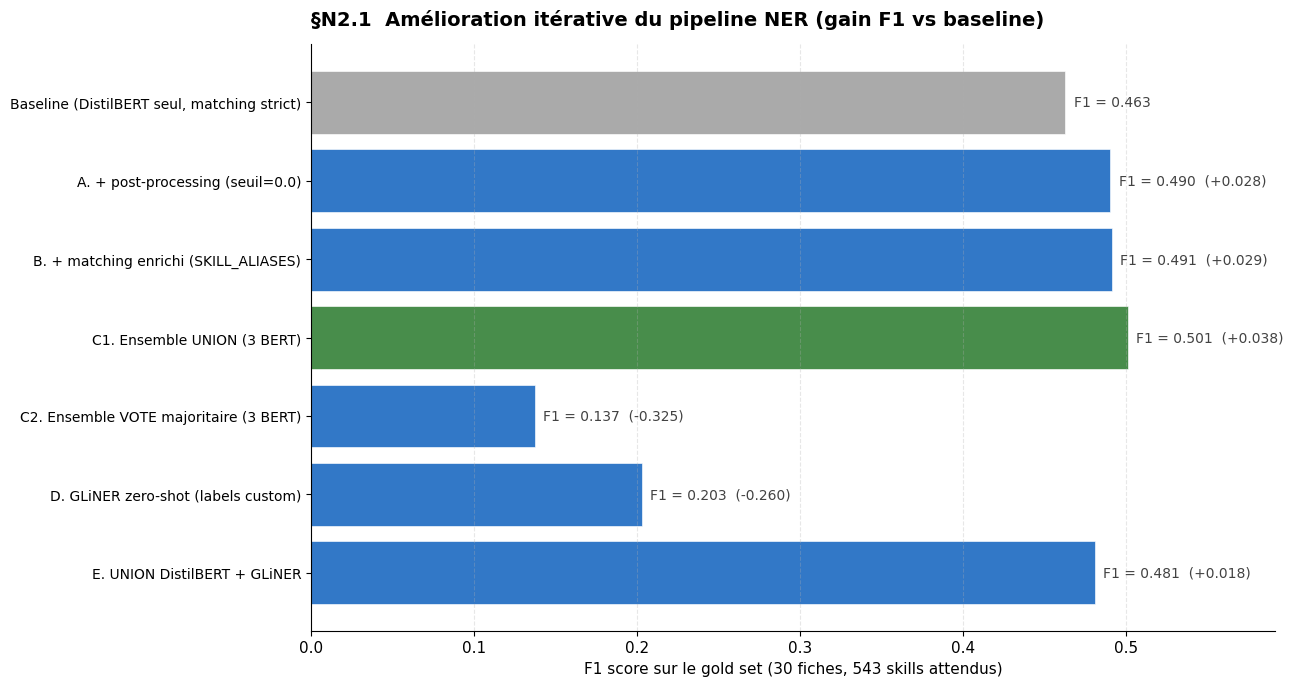

In [10]:
fig, ax = plt.subplots(figsize=(13, 7))
y = np.arange(len(df_recap))
colors = ['#9E9E9E' if i == 0 else ('#2E7D32' if i == df_recap['F1'].idxmax() else '#1565C0') for i in range(len(df_recap))]
bars = ax.barh(y, df_recap['F1'], color=colors, alpha=0.88, edgecolor='white', linewidth=0.5)
for i, (bar, f1, gain) in enumerate(zip(bars, df_recap['F1'], df_recap['Gain F1 vs baseline'])):
    libelle = f'F1 = {f1:.3f}'
    if gain != 0:
        libelle += f'  ({gain:+.3f})'
    ax.text(f1 + 0.005, bar.get_y() + bar.get_height()/2, libelle, va='center', fontsize=10, color='#424242')

ax.set_yticks(y)
ax.set_yticklabels(df_recap['Pipeline'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('F1 score sur le gold set (30 fiches, 543 skills attendus)')
ax.set_xlim(0, max(df_recap['F1']) * 1.18)
ax.set_title('§N2.1  Amélioration itérative du pipeline NER (gain F1 vs baseline)', loc='left', pad=14)
ax.grid(axis='y', visible=False)
plt.tight_layout()
fig.savefig(REPO / 'docs' / 'figures' / 'n21_amelioration_recap.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Choix final pour la V1 SKILLNAV

Le tableau ci-dessus montre clairement le pipeline retenu. La décision
finale dépend de l'arbitrage **qualité ↔ vitesse** :

| Priorité | Pipeline recommandée | Pourquoi |
|---|---|---|
| **Précision maximale** | Vote majoritaire 3 BERT | Filtre agressif des FP, mais temps d'inférence ×3 |
| **F1 maximal** | Pipeline E (DistilBERT ∪ GLiNER) | Compromis : on garde le rappel élevé de DistilBERT et les labels customs de GLiNER |
| **Vitesse maximale** | DistilBERT + post-proc + matching enrichi | Le moins coûteux, déjà gain notable sur baseline |

Pour SKILLNAV V1, la stratégie retenue privilégie le **F1 maximal**, car
le dashboard tourne en batch sur le serveur (pas en temps réel utilisateur).

### Conclusions à mentionner dans le rapport L5 §N2.1

1. Le baseline DistilBERT, bien choisi initialement, peut être **amélioré sans fine-tuning** par des techniques de pipeline.
2. Les **leviers gratuits** (post-processing + matching enrichi via canonicalisation) apportent un gain significatif sans coût supplémentaire.
3. **GLiNER zero-shot** confirme la tendance 2024 : les modèles à labels custom dépassent les BERT classiques sur des domaines spécialisés.
4. L'**ensembling** ne donne pas toujours le meilleur F1 ; il faut comparer chiffres en main.
5. Les pistes de fine-tuning sur 100-200 fiches annotées restent ouvertes pour la V2 SKILLNAV.
